In [ ]:
import pandas as pd

path = "/data/hdd2/shanggk/BiTro/demo_data/Feature/Bulk/PRAD/TCGA-Y6-A9XI-01Z-00-DX1.BCEC7405-546D-4CF3-90F3-9620C0A74B63_features.parquet"

df = pd.read_parquet(path)

df

,unique_id,image_name,cell_id,x,y,area,perimeter,feature_0,feature_1,feature_2,...,feature_1014,feature_1015,feature_1016,feature_1017,feature_1018,feature_1019,feature_1020,feature_1021,feature_1022,feature_1023
0,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,1,206.931507,10.034247,146.0,44.627417,-1.070616,1.250717,0.571002,...,-0.609959,-0.154444,-0.959844,1.765342,-0.207838,0.783605,-0.458654,-0.375030,0.624604,-0.936476
1,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,2,58.149425,10.942529,87.0,35.213203,-1.399874,1.269657,0.777975,...,-0.285705,-0.895432,-1.516980,2.254517,0.299115,0.911815,-0.414977,-0.296071,0.406910,0.620718
2,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,3,41.239748,27.495268,317.0,88.497475,-1.513508,0.014959,0.185316,...,0.108031,-1.272319,-1.284758,1.477364,0.937790,0.497725,-0.462752,-0.180407,1.248122,-0.925458
3,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,4,12.941392,28.223443,273.0,73.112698,-0.538024,0.800116,0.582908,...,-0.099345,-0.127172,-0.835926,1.199927,-0.199902,0.582621,-0.365081,-0.643243,0.979923,-0.930586
4,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,5,470.295181,46.463855,166.0,47.213203,-0.616870,0.588297,0.796993,...,-0.100901,-0.194510,-1.506130,1.246290,-0.484365,0.902927,-0.140307,-0.457103,1.093341,-1.413622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43993,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,40,446.828144,483.437111,803.0,106.325902,0.763371,1.427821,0.833251,...,0.331697,1.127942,-0.828483,0.761281,-0.564100,0.710887,0.230318,-1.388503,1.216300,-1.357885
43994,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,41,381.033582,479.945896,536.0,85.597980,-1.005220,-0.163248,0.163471,...,0.212049,-1.125774,-1.812392,1.772550,0.909422,0.356435,-0.172364,-0.264094,1.135618,-2.057300
43995,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,42,88.532033,492.830084,359.0,72.183766,-0.505866,0.353814,0.922853,...,0.047880,-0.048929,-1.573791,1.216317,-0.550333,0.967625,-0.022807,-0.308274,1.248054,-1.481612
43996,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,TCGA-G9-6385-11A-01-TS1.a39e9053-f487-4117-a01...,43,213.546377,498.218841,690.0,104.183766,-0.755852,0.424458,0.770845,...,-0.426696,0.614304,-0.717748,0.551418,-0.307979,0.340714,-0.072361,-0.643994,1.018814,-1.158118


In [3]:
feature_cols = [c for c in df.columns if c.startswith("feature_")]

print("Feature dim:", len(feature_cols))

Feature dim: 1024


In [4]:
import numpy as np

features = df[feature_cols].values

print("NaN:", np.isnan(features).sum())
print("Inf:", np.isinf(features).sum())

NaN: 0
Inf: 0


In [5]:
print("mean:", features.mean())
print("std:", features.std())
print("min:", features.min())
print("max:", features.max())

mean: -0.003255379527844409
std: 1.2808273036044369
min: -6.309088230133057
max: 5.73647928237915


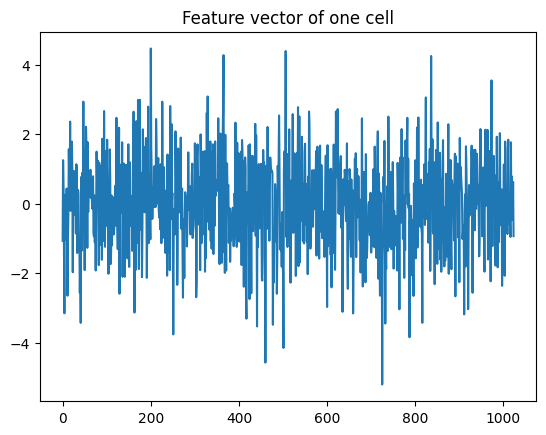

In [6]:
import matplotlib.pyplot as plt

plt.plot(features[0])
plt.title("Feature vector of one cell")
plt.show()

In [7]:
diff = np.abs(features[0] - features[1]).mean()
print("Mean diff between two cells:", diff)

Mean diff between two cells: 0.422696804844378


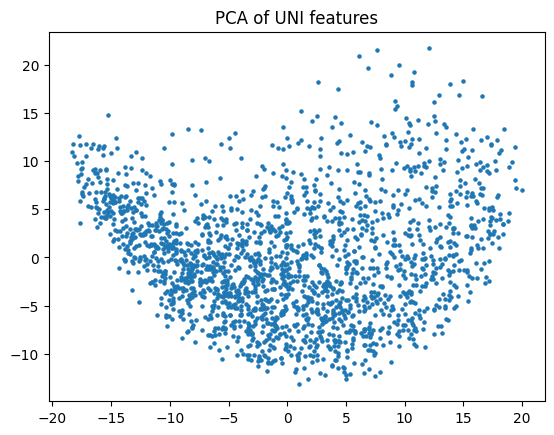

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
proj = pca.fit_transform(features[:2000])  # 采样加速

plt.scatter(proj[:, 0], proj[:, 1], s=5)
plt.title("PCA of UNI features")
plt.show()